In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle
import statsmodels.api as sm
import copernicusmarine


C:\Users\TomAH\anaconda3\envs\env_ods\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import copernicusmarine

monthly = copernicusmarine.open_dataset(
  dataset_id="cmems_obs-mob_glo_phy_my_0.125deg_P1M-m",
  variables=["mlotst", "so", "to", "ugo", "vgo", "zo"],
  minimum_longitude=-85,
  maximum_longitude=0,
  minimum_latitude=0,
  maximum_latitude=80,
  start_datetime="1993-01-01T00:00:00",
  end_datetime="2024-12-01T00:00:00",
  minimum_depth=0,
  maximum_depth=0,
)


INFO - 2026-03-05T12:08:22Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  thill


Copernicus Marine password:

  ········


INFO - 2026-03-05T12:09:40Z - Selected dataset version: "202511"
INFO - 2026-03-05T12:09:40Z - Selected dataset part: "default"


In [3]:
ds = monthly.isel(depth = 0)

In [4]:
annual_means = ds['so'].groupby('time.year').mean(dim = 'time').compute()

KeyboardInterrupt: 

In [9]:
annual_means.to_netcdf('ARMOR_3D_Salinity.nc')

In [5]:
salinity = xr.open_dataset('ARMOR_3D_salinity.nc')['so']

In [6]:
salinity 

<xarray.DataArray 'so' (year: 32, latitude: 640, longitude: 680)> Size: 111MB
[13926400 values with dtype=float64]
Coordinates:
  * year       (year) int64 256B 1993 1994 1995 1996 ... 2021 2022 2023 2024
  * latitude   (latitude) float32 3kB 0.0625 0.1875 0.3125 ... 79.69 79.81 79.94
  * longitude  (longitude) float32 3kB -84.94 -84.81 -84.69 ... -0.1875 -0.0625
    depth      int16 2B ...
Attributes:
    long_name:      salinity
    standard_name:  sea_water_salinity
    unit_long:      practical salinity unit
    units:          0.001

In [8]:
ny, nx = salinity.sizes['latitude'], salinity.sizes['longitude']
trend_data = np.full((ny, nx), np.nan, dtype = np.float32)
pval_data = np.full((ny, nx), np.nan, dtype = np.float32) 

for lat_idx in range (ny):
    for lon_idx in range (nx):
        point = salinity.isel(latitude=lat_idx, longitude=lon_idx)
        if np.isnan(point).all():
            continue
        Y = point.values
        X = sm.add_constant(point['year'].values)
        results = sm.OLS(Y, X).fit()
        trend_data[lat_idx, lon_idx] = results.params[1] 
    print(lat_idx)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [9]:
trend_da = xr.DataArray(data = trend_data, dims=["latitude", "longitude"], 
        coords={ "latitude": salinity['latitude'],
        "longitude": salinity['longitude']}, name="trend",
        attrs={'description': 'Salinity trend p-value'})


In [10]:
trend_da.to_netcdf('ARMORsalinity_trends.nc')

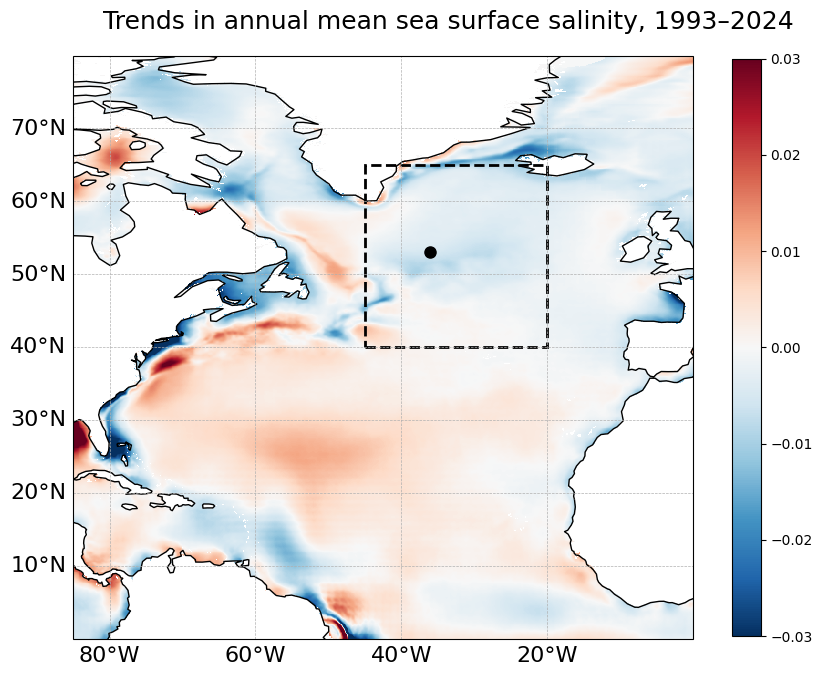

In [13]:
## Start from here in future 

trend_da = xr.open_dataset('ARMORsalinity_trends.nc')['trend']

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(trend_da['longitude'], trend_da['latitude'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -0.03, vmax = 0.03)  
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
gl.top_labels = False
gl.right_labels = False
fig.suptitle('Trends in annual mean sea surface salinity, 1993–2024',fontsize=18, y =0.63)
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)
plt.savefig('ARMOR3D_Salinity_Trends.png')
